# Customers EDA

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [42]:
customers = pd.read_csv("../04_Feature_Engineering/Output/customers_features.csv")

In [43]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_state,customer_order_count
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,"franca, SP",1
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,"sao bernardo do campo, SP",1
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,"sao paulo, SP",1
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,"mogi das cruzes, SP",1
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,"campinas, SP",1


In [44]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
 5   customer_city_state       99441 non-null  object
 6   customer_order_count      99441 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 5.3+ MB


In [45]:
customers.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_state,customer_order_count
count,99441,99441,99441.000000,99441,99441,99441,99441.0
unique,99441,96096,NaN,4119,27,4310,NaN
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP,"sao paulo, SP",NaN
freq,1,17,NaN,15540,41746,15540,NaN
mean,NaN,NaN,35137.474583,NaN,NaN,NaN,1.0
std,NaN,NaN,29797.938996,NaN,NaN,NaN,0.0
min,NaN,NaN,1003.000000,NaN,NaN,NaN,1.0
25%,NaN,NaN,11347.000000,NaN,NaN,NaN,1.0
50%,NaN,NaN,24416.000000,NaN,NaN,NaN,1.0
75%,NaN,NaN,58900.000000,NaN,NaN,NaN,1.0


In [46]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
customer_city_state         0
customer_order_count        0
dtype: int64

In [47]:
customers.duplicated().sum()

0

## Geographic Analysis

**Frequency Count**

In [48]:
customers["customer_state"].value_counts().reset_index()

,customer_state,count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


**Percentage Distribution**

In [49]:
state_pct = (
    customers["customer_state"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

state_pct.columns = ["customer_state", "percentage"]

state_pct

,customer_state,percentage
0,SP,41.98
1,RJ,12.92
2,MG,11.70
3,RS,5.50
4,PR,5.07
5,SC,3.66
6,BA,3.40
7,DF,2.15
8,ES,2.04
9,GO,2.03


**Count Plot**

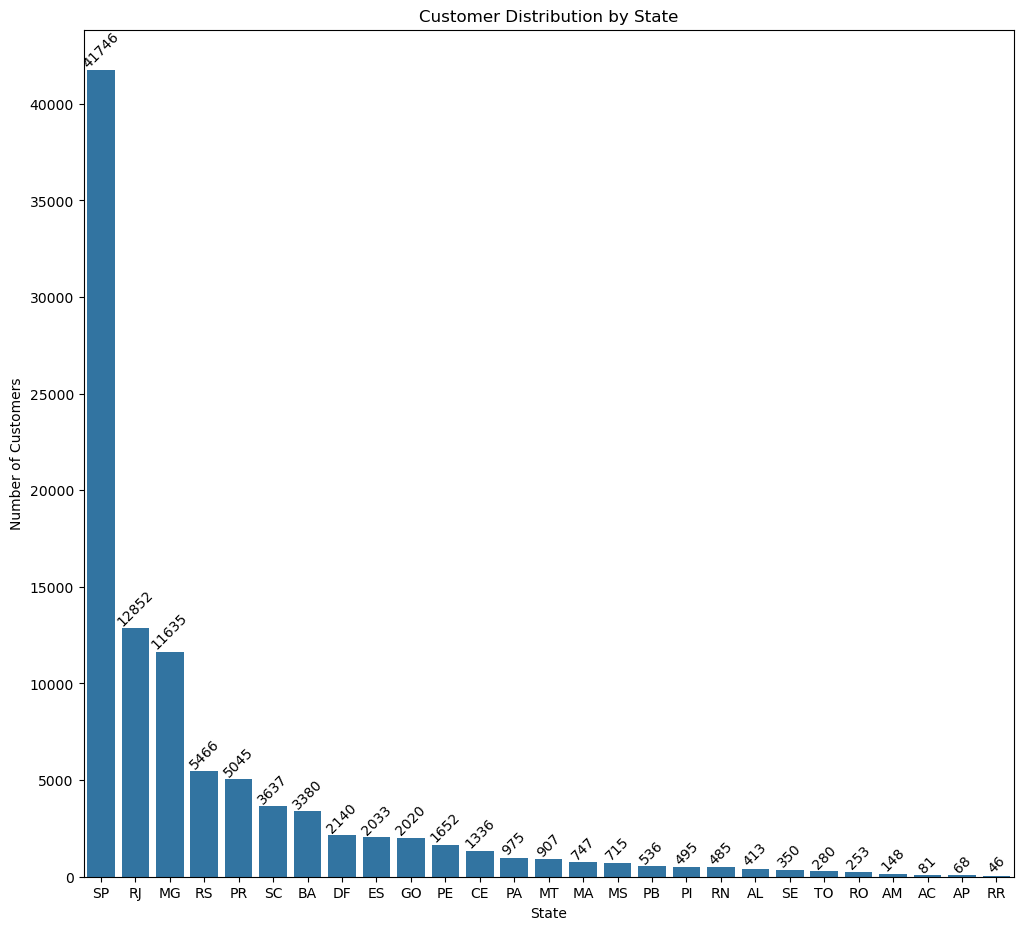

In [50]:
plt.figure(figsize=(12,11))

ax = sns.countplot(
    data=customers,
    x="customer_state",
    order=customers["customer_state"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, rotation = 45)

plt.title("Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.show()

**Percentage Bar Chart**

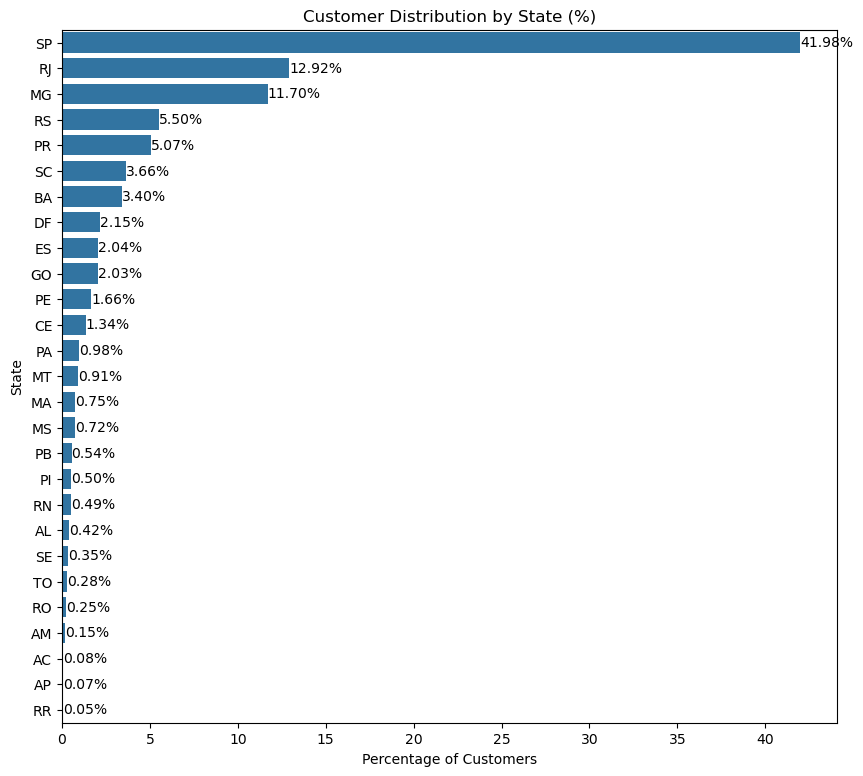

In [51]:
plt.figure(figsize=(10,9))

ax = sns.barplot(
    data=state_pct,
    x="percentage",
    y="customer_state"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", rotation=0)

plt.title("Customer Distribution by State (%)")
plt.xlabel("Percentage of Customers")
plt.ylabel("State")

plt.show()

### Business Insights

**Insight 1**
The customer base is highly concentrated, with 66.6% of customers located in São Paulo (SP), Rio de Janeiro (RJ), and Minas Gerais (MG). These states should remain the primary focus for customer retention initiatives, logistics optimization, and service quality improvements.

**Insight 2**
States with the largest customer populations are likely to generate the highest order volumes. Investments in warehousing, fulfillment centers, and customer support in these regions are likely to have the greatest operational impact.

**Insight 3**
States with very low customer representation may indicate opportunities for market expansion. Targeted marketing campaigns and regional partnerships could help increase customer acquisition in these underserved areas.

**Insight 4**
The uneven geographic distribution suggests that Olist's business is concentrated in a few key markets. When evaluating overall business performance, analysts should account for this geographic imbalance, as trends in SP, RJ, and MG may disproportionately influence company-wide metrics.

## Customer City Analysis(Top 20)

In [52]:
top_cities = customers["customer_city"].value_counts().head(20)

top_cities

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
sao jose dos campos        691
fortaleza                  654
sorocaba                   633
recife                     613
florianopolis              570
Name: count, dtype: int64

In [53]:
# Converting it to a dataframe 
city_df = top_cities.reset_index()
city_df.columns = ["customer_city", "count"]

city_df.head()

,customer_city,count
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521


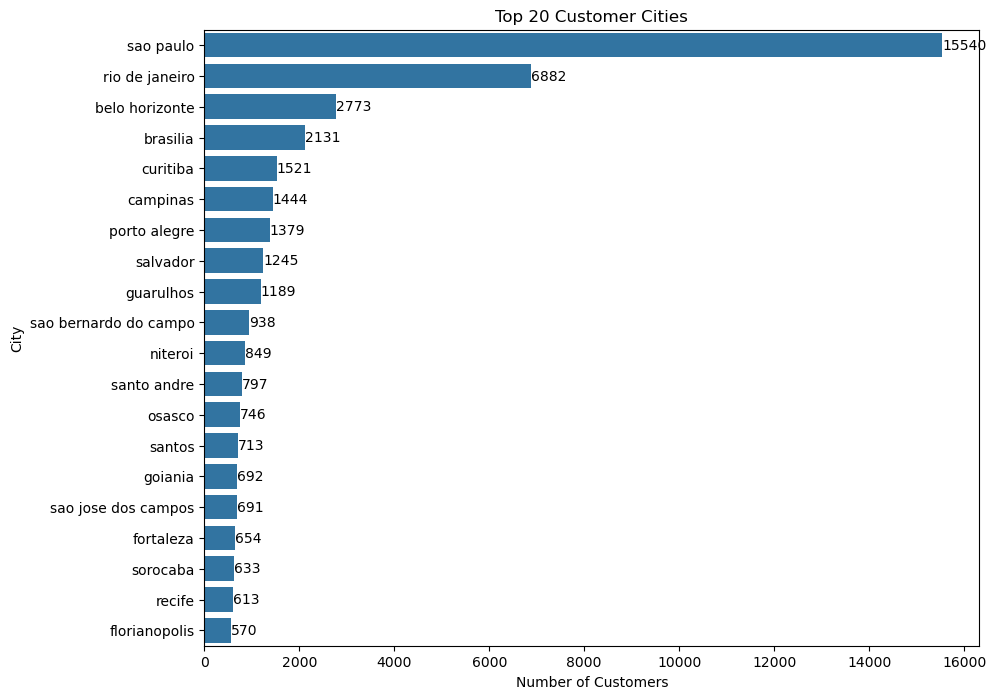

In [54]:
plt.figure(figsize=(10,8))

ax = sns.barplot(
    data=city_df,
    x="count",
    y="customer_city"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 20 Customer Cities")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.show()

### Business Insights
**Insight 1**
Olist's customer base is concentrated in Brazil's major urban centers, suggesting that large metropolitan areas are the company's strongest markets.

**Insight 2**
São Paulo city alone represents a substantial portion of the customer base, making it a strategic location for logistics infrastructure, marketing campaigns, and customer service investments.

**Insight 3**
The presence of multiple large cities among the top customer locations indicates broad adoption across several metropolitan regions rather than dependence on a single city.

**Insight 4**
Understanding customer concentration by city can support decisions related to warehouse placement, delivery optimization, and region-specific promotional campaigns.

## Customer City-State Analysis(Top 20)

In [62]:
customer_city_state = customers["customer_city_state"].value_counts().head(20).reset_index()

customer_city_state.columns = ["customer_city_state", "Count"]

customer_city_state

,customer_city_state,Count
0,"sao paulo, SP",15540
1,"rio de janeiro, RJ",6882
2,"belo horizonte, MG",2773
3,"brasilia, DF",2131
4,"curitiba, PR",1521
5,"campinas, SP",1444
6,"porto alegre, RS",1379
7,"salvador, BA",1245
8,"guarulhos, SP",1189
9,"sao bernardo do campo, SP",938


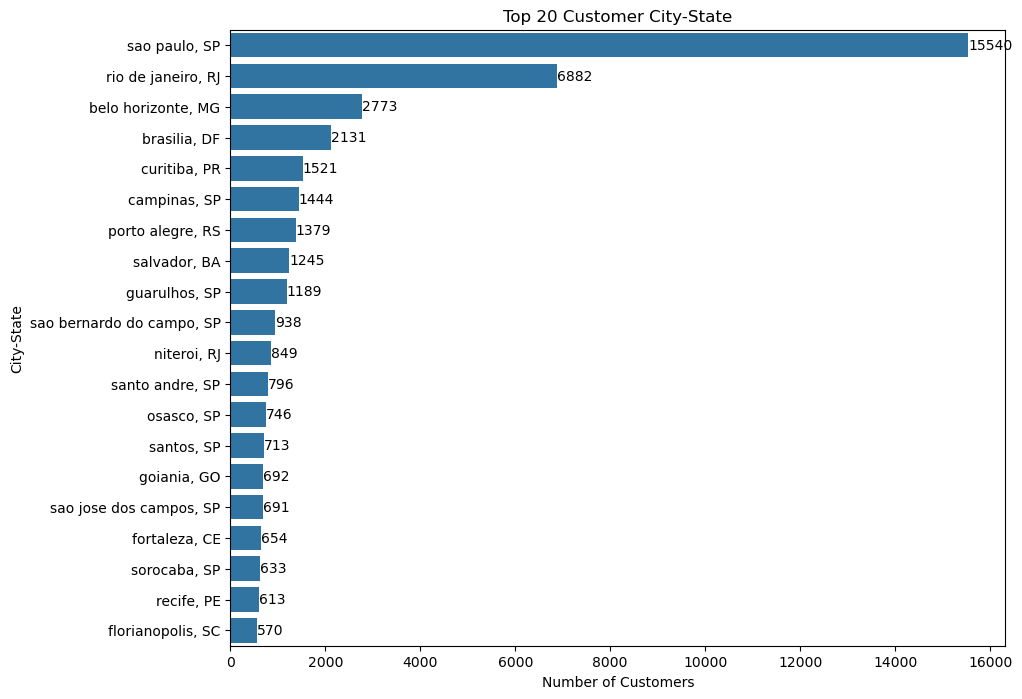

In [61]:
plt.figure(figsize=(10,8))

ax = sns.barplot(
    data = customer_city_state,
    x = "Count",
    y = "customer_city_state"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 20 Customer City-State")
plt.xlabel("Number of Customers")
plt.ylabel("City-State")

plt.show()

### Business Insights

**Insight 1**
The highest customer concentrations are located in Brazil's largest metropolitan areas, suggesting that urban regions are Olist's primary customer markets.

**Insight 2**
The strong presence of multiple cities within São Paulo state highlights the importance of this region for logistics, warehouse placement, marketing campaigns, and customer support operations.

**Insight 3**
Customer concentration across several major cities indicates that Olist has achieved broad penetration in Brazil's urban markets rather than relying on a single geographic location.

**Insight 4**
The `customer_city_state` feature provides a more precise geographic identifier than `customer_city` alone, making it better suited for reporting and location-based business analysis.

## Overall Observations

**Observation 1**
The customer base is highly concentrated in a few states, with São Paulo (SP) alone accounting for 41.98% of all customers.

**Observation 2**
The top three states (SP, RJ, and MG) together represent 66.60% of the total customer base, indicating a strong geographic concentration.

**Observation 3**
Customer acquisition is primarily concentrated in Brazil's major metropolitan areas, with São Paulo, Rio de Janeiro, Belo Horizonte, Brasília, and Curitiba being the largest customer locations.

**Observation 4**
The customer_city_state feature provides a more precise geographic representation than customer_city, making it more suitable for location-based reporting and analysis.

## Overall Business Insights

**Insight 1**
The strong concentration of customers in the Southeast region suggests that this area should remain the primary focus for customer retention strategies, logistics optimization, and service quality improvements.

**Insight 2**
High customer density in major metropolitan areas presents opportunities to optimize warehouse placement, reduce delivery times, and improve last-mile logistics.

**Insight 3**
States and cities with relatively low customer representation may offer opportunities for future market expansion through targeted marketing campaigns and regional partnerships.

**Insight 4**
Geographic customer distribution should be considered when interpreting business metrics, as performance trends in high-volume regions such as São Paulo, Rio de Janeiro, and Minas Gerais can significantly influence overall company performance.